#**1. Loading Data**


In [ ]:
import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/Project/Regression - Zone3.xlsx',index_col=None)

data.head()

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,A3
0,191,241,238,236,249,8.2,8514,1321,45,3.0
1,194,240,235,234,251,8.2,7184,1158,45,5.0
2,194,241,233,234,249,8.2,8546,1350,50,7.0
3,194,242,242,234,250,8.7,8337,1427,50,1.5
4,195,239,239,237,250,8.3,8262,1409,45,2.0


In [ ]:
len(data)

269

# **2. Preparing Data**

In [ ]:
# Split into X and y

X = data.drop('A3', axis=1)
y = data['A3']

In [ ]:
X

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
0,191,241,238,236,249,8.2,8514,1321,45
1,194,240,235,234,251,8.2,7184,1158,45
2,194,241,233,234,249,8.2,8546,1350,50
3,194,242,242,234,250,8.7,8337,1427,50
4,195,239,239,237,250,8.3,8262,1409,45
...,...,...,...,...,...,...,...,...,...
264,195,233,236,237,251,7.9,8276,1388,50
265,183,233,230,232,252,7.9,7986,1331,45
266,183,233,237,233,251,7.9,7969,1384,45
267,188,231,241,237,250,9.3,8065,1288,40


In [ ]:
y

0      3.0
1      5.0
2      7.0
3      1.5
4      2.0
      ... 
264    4.0
265    9.0
266    2.0
267    1.5
268    8.0
Name: A3, Length: 269, dtype: float64

In [ ]:
# Split data into training and test data

from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
115,194,239,239,238,252,7.50,8300,1435,40
33,192,242,238,241,250,8.10,8544,1471,40
180,191,239,241,238,250,7.70,8085,1270,45
141,190,236,235,235,251,7.40,8495,1445,40
248,187,235,238,238,249,7.90,8257,1350,45
...,...,...,...,...,...,...,...,...,...
20,196,241,238,235,249,8.40,8591,1299,50
188,191,239,234,237,249,7.75,8067,1325,35
71,194,238,236,236,249,7.90,8232,1312,35
106,186,237,238,239,250,7.50,8290,1335,40


In [ ]:
X_test

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
30,194,238,240,237,250,8.10,8374,1459,50
116,194,238,236,234,251,7.50,8460,1470,35
79,186,242,239,234,250,8.50,8481,1310,40
127,189,239,238,233,249,7.50,8377,1419,45
190,191,240,237,235,248,7.50,8322,1403,45
137,191,240,242,241,251,7.50,8258,1318,50
202,191,241,233,235,251,7.75,8271,1430,45
45,191,241,238,235,249,8.20,8314,1470,45
173,192,232,237,236,251,7.70,8251,1290,50
239,191,239,235,235,251,8.50,8135,1440,45


In [ ]:
y_train

115    1.5
33     3.0
180    1.5
141    7.0
248    2.0
      ... 
20     3.0
188    5.0
71     4.0
106    2.0
102    2.0
Name: A3, Length: 215, dtype: float64

In [ ]:
y_test

30      2.0
116     5.0
79      2.0
127     2.0
190     3.0
137     1.5
202     7.0
45      2.0
173     3.0
239     4.0
179     2.0
267     1.5
220     1.5
82      1.5
186     4.0
185     3.0
241     6.0
265     9.0
104     5.0
60      3.0
261    10.0
184     1.5
46      3.0
42      1.5
181     1.5
9       9.0
22      2.0
193     1.5
109     4.0
24      1.5
113     3.0
68      1.5
143     1.5
217     2.0
197     5.0
6       3.0
120     1.5
67      1.5
119     5.0
118     8.0
25      4.0
125     3.0
165     1.5
19      8.0
77      1.5
209     7.0
90      1.5
170    10.0
93      4.0
258     6.0
15      3.0
150     6.0
224     6.0
242     4.0
Name: A3, dtype: float64

In [ ]:
y_test.value_counts()

1.5     16
3.0      9
2.0      7
4.0      6
5.0      4
6.0      4
7.0      2
9.0      2
10.0     2
8.0      2
Name: A3, dtype: int64

In [ ]:
y_train.value_counts()

1.5     69
2.0     30
4.0     22
3.0     21
5.0     21
6.0     16
7.0     14
8.0     11
10.0     6
9.0      4
16.0     1
Name: A3, dtype: int64

##Pearson Correlation  (detecting correlated data)

<function matplotlib.pyplot.show(*args, **kw)>

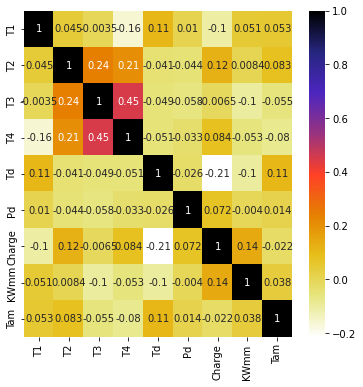

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Using Pearson Correlation
plt.figure(figsize=(6,6))
cor = X.corr(method='pearson')
#cor2 = X.corr(method='spearman')
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
#sns.heatmap(cor2, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

# **3. Building Machine Learning Model**

## All Models

In [ ]:
!pip install catboost
!pip install logitboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 129 kB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# 3.1. Ridge Model

In [ ]:
from sklearn.linear_model import Ridge
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
model = Ridge()
model.fit(X_train, y_train)

Ridge()

In [ ]:
#Evaluate our model
model.score(X_test, y_test)

0.9023528205832803

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([  0.70734094,   0.67826225,   0.88068552, -10.60405642,
         0.90269454])

In [ ]:
#Use the trained model to make predictions

y_preds = model.predict(X_test)
#y_preds[:10]
y_preds

array([1.69839539, 4.93719231, 2.93018164, 3.27611376, 3.90895658,
       0.17458811, 6.75417351, 3.24840948, 3.40207883, 5.03466342,
       2.75078577, 0.4499098 , 1.98523167, 0.89749913, 5.0190404 ,
       3.65165331, 5.7996418 , 8.2584971 , 5.3922773 , 4.12830599,
       8.81452499, 2.22037274, 3.75725872, 0.21070447, 1.47392494,
       9.05235265, 1.81930633, 2.34017668, 4.64171812, 1.16875191,
       3.31504153, 1.04049048, 0.36141916, 3.09850989, 5.47204425,
       4.09534601, 0.0556207 , 1.90157163, 5.11439198, 7.67433004,
       4.92873414, 3.97931659, 1.6488773 , 7.19009412, 1.28602201,
       6.23528568, 1.00862156, 8.85581536, 4.14110928, 5.65741496,
       3.83504776, 5.58588014, 6.22217832, 4.43466861])

In [ ]:
#y_test[:10]
y_test

30      2.0
116     5.0
79      2.0
127     2.0
190     3.0
137     1.5
202     7.0
45      2.0
173     3.0
239     4.0
179     2.0
267     1.5
220     1.5
82      1.5
186     4.0
185     3.0
241     6.0
265     9.0
104     5.0
60      3.0
261    10.0
184     1.5
46      3.0
42      1.5
181     1.5
9       9.0
22      2.0
193     1.5
109     4.0
24      1.5
113     3.0
68      1.5
143     1.5
217     2.0
197     5.0
6       3.0
120     1.5
67      1.5
119     5.0
118     8.0
25      4.0
125     3.0
165     1.5
19      8.0
77      1.5
209     7.0
90      1.5
170    10.0
93      4.0
258     6.0
15      3.0
150     6.0
224     6.0
242     4.0
Name: A3, dtype: float64

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error, max_error
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.587389977417243
mean_absolute_error= 0.65774648808191
mean_absolute_percentage_error= 0.2708440693985422
median_absolute_error= 0.6466857131337349
max_error= 1.444379301392388


# 3.2. Random Forest Regression Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
rf = RandomForestRegressor(max_depth= 20,
 max_features= 'auto',
 min_samples_leaf= 1,
 min_samples_split= 8,
 n_estimators= 100)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=8)

In [ ]:
#Evaluate our model
rf.score(X_test, y_test)

0.9256042772441551

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=5)

array([0.81216612, 0.93728109, 0.94960414, 0.88302914, 0.88137389])

In [ ]:
y_preds = rf.predict(X_test)
y_preds

array([1.50071429, 4.7997943 , 2.05305233, 2.16780733, 3.42344336,
       1.5       , 6.9757504 , 2.17258881, 2.78923901, 5.19298442,
       1.74328778, 2.72163399, 4.16472024, 2.72564472, 5.14667764,
       2.66629456, 6.07896806, 9.70156654, 5.24150142, 3.31924495,
       8.97524786, 1.54663095, 3.01532767, 1.62177976, 1.50333333,
       8.9785812 , 1.63111171, 1.60248779, 3.97977814, 1.50844156,
       4.54494994, 1.58677976, 1.514     , 2.31864376, 5.06865221,
       3.87672691, 1.508     , 1.57408333, 5.15402299, 8.40413814,
       4.59219956, 3.06948107, 2.09691667, 8.15290455, 2.70540906,
       5.89581324, 1.504     , 8.9343312 , 3.46364978, 5.6825219 ,
       2.95455783, 5.4707508 , 5.92122552, 4.15962038])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.4475224186763639
mean_absolute_error= 0.42362432777220355
mean_absolute_percentage_error= 0.1639494160281922
median_absolute_error= 0.2054833475348179
max_error= 2.6647202380952377


## 3.3. KNeighbours Regression Model

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
neigh = KNeighborsRegressor(n_neighbors = 50)
neigh.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=50)

In [ ]:
#Evaluate our model
neigh.score(X_test, y_test)

-0.011865674704977014

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(neigh, X, y, cv=5)

array([-0.00139636, -0.25346244, -0.01164954, -0.09281098, -0.19339254])

In [ ]:
y_preds = neigh.predict(X_test)
y_preds

array([3.59, 4.  , 3.86, 3.65, 3.67, 3.65, 4.37, 4.  , 3.56, 3.85, 3.24,
       3.19, 3.88, 3.22, 3.5 , 3.53, 3.65, 3.2 , 4.29, 3.69, 3.48, 3.27,
       4.25, 3.56, 4.06, 3.67, 3.98, 3.94, 4.41, 4.25, 3.73, 3.8 , 3.39,
       3.89, 4.25, 3.96, 4.26, 3.16, 3.91, 3.66, 3.92, 3.99, 4.2 , 4.22,
       3.79, 4.03, 3.56, 3.29, 3.51, 3.78, 3.39, 3.87, 3.92, 3.87])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 6.086809259259259
mean_absolute_error= 1.9690740740740738
mean_absolute_percentage_error= 0.7185740740740739
median_absolute_error= 1.875
max_error= 6.71


# 3.4. DecisionTree Regression Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
dt = DecisionTreeRegressor(random_state=1)
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=1)

In [ ]:
#Evaluate our model
dt.score(X_test, y_test)

0.8175987685992817

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(dt, X, y, cv=5)

array([0.7880558 , 0.79979817, 0.92560237, 0.74651494, 0.82534908])

In [ ]:
y_preds = dt.predict(X_test)
y_preds

array([ 1.5,  6. ,  2. ,  2. ,  3. ,  1.5,  7. ,  2. ,  3. ,  5. ,  1.5,
        5. ,  1.5,  5. ,  5. ,  3. ,  6. , 10. ,  6. ,  3. ,  8. ,  1.5,
        3. ,  1.5,  1.5,  8. ,  1.5,  1.5,  4. ,  1.5,  7. ,  1.5,  1.5,
        2. ,  5. ,  4. ,  1.5,  1.5,  5. ,  8. ,  5. ,  3. ,  1.5,  8. ,
        1.5,  7. ,  1.5,  8. ,  3. ,  6. ,  3. ,  6. ,  5. ,  4. ])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 1.0972222222222223
mean_absolute_error= 0.49074074074074076
mean_absolute_percentage_error= 0.17170781893004114
median_absolute_error= 0.0
max_error= 4.0


# 3.5. XGBOOST Regressor

In [ ]:
from xgboost import XGBRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
xgb = XGBRegressor( max_depth=50, learning_rate=0.1, n_estimators=100)
xgb.fit(X_train,y_train)

[06:10:52] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


XGBRegressor(max_depth=50)

In [ ]:
#Evaluate our model
xgb.score(X_test, y_test)

0.8349254030577105

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(xgb, X, y, cv=5)

[06:10:52] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:10:52] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:10:52] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:10:52] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:10:52] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


array([0.70738765, 0.89353188, 0.93832553, 0.85940234, 0.87143043])

In [ ]:
y_preds = xgb.predict(X_test)
y_preds

array([1.5022897, 4.513216 , 1.6704448, 2.1932697, 3.995792 , 1.5000874,
       6.9798913, 2.3749104, 2.9300175, 5.1522036, 1.6799384, 4.2091713,
       6.69878  , 1.4475628, 4.8126993, 2.917211 , 6.042807 , 9.50207  ,
       4.9805284, 3.1427863, 9.842054 , 1.5197417, 3.072591 , 1.4982289,
       1.5002149, 9.765753 , 1.6202306, 1.9068698, 3.4536903, 1.5020434,
       5.242734 , 1.4996784, 1.50071  , 2.2063687, 4.9874167, 3.83795  ,
       1.5011669, 1.526909 , 5.0345473, 8.061384 , 4.798316 , 3.0900767,
       1.5689815, 8.245203 , 4.030642 , 7.0718665, 1.5046155, 9.420177 ,
       3.3770635, 6.203282 , 3.0952861, 6.452819 , 5.9173427, 3.9892585],
      dtype=float32)

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.9929950291374141
mean_absolute_error= 0.4747853323265358
mean_absolute_percentage_error= 0.21364152967264063
median_absolute_error= 0.150365948677063
max_error= 5.198780059814453


#3.6. CATBOOST Regressor


In [ ]:
from catboost import CatBoostRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
catb = CatBoostRegressor(iterations=2, learning_rate=1, depth=2)
# Fit model
catb.fit(X_train, y_train)

0:	learn: 1.6447484	total: 46.6ms	remaining: 46.6ms
1:	learn: 1.1857790	total: 46.8ms	remaining: 0us


In [ ]:
#Evaluate our model
catb.score(X_test, y_test)

0.8328456670752897

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(catb, X, y, cv=5)

0:	learn: 1.3891785	total: 251us	remaining: 251us
1:	learn: 1.1392578	total: 495us	remaining: 0us
0:	learn: 1.4539702	total: 246us	remaining: 246us
1:	learn: 1.2044035	total: 467us	remaining: 0us
0:	learn: 1.4561039	total: 234us	remaining: 234us
1:	learn: 1.2257717	total: 959us	remaining: 0us
0:	learn: 1.6306297	total: 262us	remaining: 262us
1:	learn: 1.1188182	total: 958us	remaining: 0us
0:	learn: 1.2503115	total: 252us	remaining: 252us
1:	learn: 1.0009654	total: 484us	remaining: 0us


array([0.52592763, 0.68968641, 0.69125473, 0.66067775, 0.78255902])

In [ ]:
y_preds = catb.predict(X_test)
y_preds

array([2.28162581, 3.94112461, 2.28162581, 1.76580383, 3.94112461,
       1.76580383, 8.63438795, 2.28162581, 3.94112461, 4.43231615,
       1.76580383, 2.28162581, 1.6920747 , 2.28162581, 3.94112461,
       3.94112461, 4.43231615, 8.53602838, 3.94112461, 4.43231615,
       8.86629988, 1.76580383, 4.43231615, 1.6920747 , 1.76580383,
       8.86629988, 2.28162581, 1.76580383, 3.94112461, 2.28162581,
       1.76580383, 1.6920747 , 1.76580383, 1.6920747 , 3.94112461,
       4.43231615, 1.76580383, 1.6920747 , 3.94112461, 8.53602838,
       4.43231615, 3.94112461, 1.76580383, 8.86629988, 2.28162581,
       3.94112461, 1.76580383, 8.63438795, 3.94112461, 3.84276503,
       4.43231615, 3.94112461, 3.84276503, 3.84276503])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 1.0055055397230253
mean_absolute_error= 0.7633261569937473
mean_absolute_percentage_error= 0.22544216524363495
median_absolute_error= 0.5
max_error= 3.058875391715519


##Results

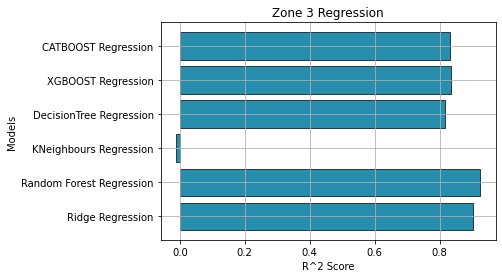

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_valeues=['Ridge Regression', 'Random Forest Regression','KNeighbours Regression', 'DecisionTree Regression',
           'XGBOOST Regression', 'CATBOOST Regression']

y_valeues=[model.score(X_test, y_test), rf.score(X_test, y_test), neigh.score(X_test, y_test), dt.score(X_test, y_test),
           xgb.score(X_test, y_test), catb.score(X_test, y_test)]


width=1

# plot
plt.barh(x_valeues, y_valeues, color='#288ead', edgecolor="black", linewidth=0.7)

plt.xlabel('R^2 Score')
plt.ylabel('Models')
plt.title('Zone 3 Regression')
plt.grid(True)

plt.show()